In [1]:
from fod_features import extract_features
from fod_quant import FeatureScaler

In [2]:
image_path = r"D:\PROJECTS\64feature_NN\RGB_NN\dataset\train\fuelcap\image_00077.png"

features, debug = extract_features(
    image_path,
    return_debug=True
)

print("Shape:", features.shape)
print("Min:", features.min())
print("Max:", features.max())
print("Object found:", debug["found"])
print("Mask area:", debug["mask"].sum())

Shape: (64,)
Min: -10.594955
Max: 57.051193
Object found: True
Mask area: 1263


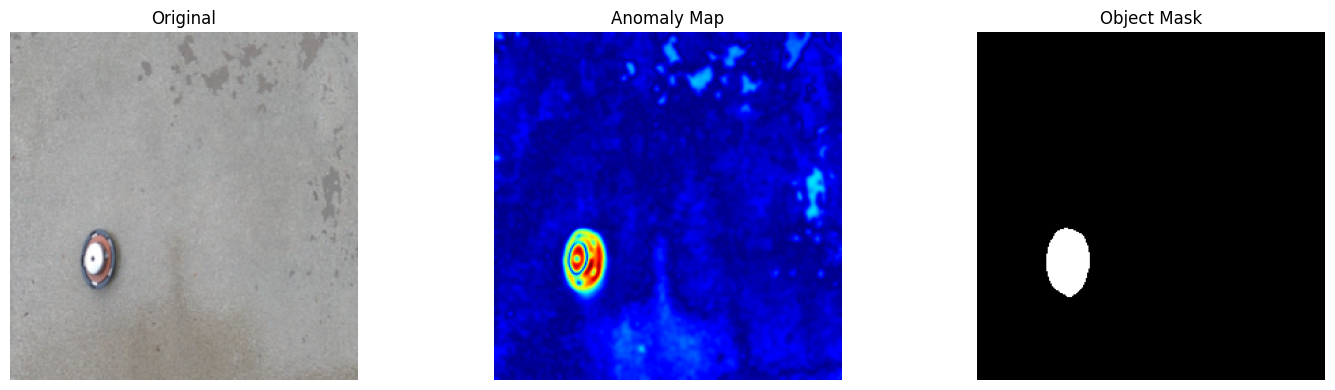

In [3]:
import matplotlib.pyplot as plt
import cv2

bgr = debug["bgr"]
mask = debug["mask"]
anomaly = debug["anomaly"]

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(anomaly, cmap="jet")
plt.title("Anomaly Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask, cmap="gray")
plt.title("Object Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Feature names and values

from fod_features import FEATURE_NAMES

print("Number of features:", len(features))
print()

for i, (name, value) in enumerate(zip(FEATURE_NAMES, features)):
    print(f"{i:2d}: {name:25s} {value:10.5f}")

Number of features: 64

 0: L_mean                      57.05119
 1: a_mean                       3.76868
 2: b_mean                      -1.67665
 3: L_std                       21.05034
 4: a_std                        6.40414
 5: b_std                        7.31693
 6: hue_cos                      0.29041
 7: hue_sin                     -0.12920
 8: chroma_mean                  0.07977
 9: hue_hist_0                   0.00284
10: hue_hist_1                   0.08142
11: hue_hist_2                   0.19691
12: hue_hist_3                   0.03821
13: hue_hist_4                   0.26154
14: hue_hist_5                   0.01647
15: hue_hist_6                   0.01624
16: hue_hist_7                   0.00108
17: highlight_frac               0.17577
18: dL                         -10.59496
19: da                           3.64874
20: db                          -1.91690
21: dE_mean                     19.78116
22: dE_max                      33.91968
23: boundary_grad                

In [5]:
from pathlib import Path
import numpy as np
import json
import time

from fod_features import (
    extract_features,
    FEATURE_NAMES,
    N_FEATURES
)

from fod_quant import FeatureScaler


# ============================================================
# PATHS
# ============================================================

DATASET_ROOT = Path(
    r"D:\PROJECTS\64feature_NN\RGB_NN\dataset"
)

OUTPUT_DIR = Path(
    r"D:\PROJECTS\64feature_NN\RGB_NN\features"
)

SPLITS = [
    "train",
    "validation",
    "test"
]

EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp"
}

print("Dataset:", DATASET_ROOT)
print("Output :", OUTPUT_DIR)

Dataset: D:\PROJECTS\64feature_NN\RGB_NN\dataset
Output : D:\PROJECTS\64feature_NN\RGB_NN\features


Make sure this prints the correct paths.

Cell 5A — detect your classes

In [6]:
# ============================================================
# FIND CLASSES
# ============================================================

train_dir = DATASET_ROOT / "train"

CLASS_NAMES = sorted([
    p.name
    for p in train_dir.iterdir()
    if p.is_dir()
])

CLASS_TO_ID = {
    name: i
    for i, name in enumerate(CLASS_NAMES)
}

print("Classes:")
for name, idx in CLASS_TO_ID.items():
    print(f"{idx}: {name}")

Classes:
0: fuelcap
1: pliers
2: screwdrivers
3: sodacan


Cell 5B — function to process a split

In [9]:
def process_split(split_name):

    split_dir = DATASET_ROOT / split_name

    all_features = []
    all_labels = []
    all_paths = []

    print()
    print("=" * 60)
    print(f"PROCESSING: {split_name.upper()}")
    print("=" * 60)

    start_time = time.perf_counter()

    for class_name in CLASS_NAMES:

        class_dir = split_dir / class_name

        if not class_dir.exists():
            print(
                f"WARNING: {class_dir} does not exist"
            )
            continue

        image_files = sorted([
            p for p in class_dir.iterdir()
            if (
                p.is_file()
                and p.suffix.lower() in EXTENSIONS
            )
        ])

        label = CLASS_TO_ID[class_name]

        print(
            f"\n{class_name}: {len(image_files)} images"
        )

        successful = 0
        failed = 0
        no_object = 0

        for i, image_path in enumerate(image_files):

            try:

                f, debug = extract_features(
                    image_path,
                    return_debug=True
                )

                all_features.append(f)
                all_labels.append(label)
                all_paths.append(str(image_path))

                successful += 1

                if not debug["found"]:
                    no_object += 1

            except Exception as e:

                failed += 1

                print(
                    f"\nERROR: {image_path}"
                )

                print(
                    f"       {e}"
                )

            # Progress
            if (
                (i + 1) % 50 == 0
                or
                i == len(image_files) - 1
            ):

                print(
                    f"\r  Progress: "
                    f"{i+1}/{len(image_files)}",
                    end=""
                )

        print()

        print(
            f"  Successful : {successful}"
        )

        print(
            f"  Errors     : {failed}"
        )

        print(
            f"  No object  : {no_object}"
        )

    # --------------------------------------------------------
    # Convert to NumPy
    # --------------------------------------------------------

    X = np.asarray(
        all_features,
        dtype=np.float32
    )

    y = np.asarray(
        all_labels,
        dtype=np.int64
    )

    paths = np.asarray(
        all_paths
    )

    # --------------------------------------------------------
    # Verify
    # --------------------------------------------------------

    print()
    print(f"{split_name} result:")
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    assert X.ndim == 2
    assert X.shape[1] == 64
    assert X.shape[0] == y.shape[0]

    elapsed = (
        time.perf_counter()
        - start_time
    )

    print(
        f"Time: {elapsed:.2f} seconds"
    )

    return X, y, paths

Cell 5C — process train, validation and test

In [10]:
X_train, y_train, paths_train = process_split("train")


PROCESSING: TRAIN

fuelcap: 301 images
  Progress: 301/301
  Successful : 301
  Errors     : 0
  No object  : 0

pliers: 597 images
  Progress: 597/597
  Successful : 597
  Errors     : 0
  No object  : 0

screwdrivers: 428 images
  Progress: 428/428
  Successful : 428
  Errors     : 0
  No object  : 0

sodacan: 544 images
  Progress: 544/544
  Successful : 544
  Errors     : 0
  No object  : 0

train result:
X shape: (1870, 64)
y shape: (1870,)
Time: 118.64 seconds


In [12]:
X_val, y_val, paths_val = process_split("validation")


PROCESSING: VALIDATION

fuelcap: 66 images
  Progress: 66/66
  Successful : 66
  Errors     : 0
  No object  : 0

pliers: 130 images
  Progress: 130/130
  Successful : 130
  Errors     : 0
  No object  : 0

screwdrivers: 83 images
  Progress: 83/83
  Successful : 83
  Errors     : 0
  No object  : 0

sodacan: 105 images
  Progress: 105/105
  Successful : 105
  Errors     : 0
  No object  : 0

validation result:
X shape: (384, 64)
y shape: (384,)
Time: 23.42 seconds


In [13]:
X_test, y_test, paths_test = process_split("test")


PROCESSING: TEST

fuelcap: 62 images
  Progress: 62/62
  Successful : 62
  Errors     : 0
  No object  : 0

pliers: 126 images
  Progress: 126/126
  Successful : 126
  Errors     : 0
  No object  : 0

screwdrivers: 97 images
  Progress: 97/97
  Successful : 97
  Errors     : 0
  No object  : 0

sodacan: 127 images
  Progress: 127/127
  Successful : 127
  Errors     : 0
  No object  : 0

test result:
X shape: (412, 64)
y shape: (412,)
Time: 27.31 seconds


Cell 5D — inspect the results

In [14]:
print("TRAIN")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nVALIDATION")
print("X:", X_val.shape)
print("y:", y_val.shape)

print("\nTEST")
print("X:", X_test.shape)
print("y:", y_test.shape)

TRAIN
X: (1870, 64)
y: (1870,)

VALIDATION
X: (384, 64)
y: (384,)

TEST
X: (412, 64)
y: (412,)


In [15]:
print("\nTRAIN CLASS DISTRIBUTION")

for name, idx in CLASS_TO_ID.items():
    print(
        f"{idx}: {name:15s}",
        np.sum(y_train == idx)
    )


TRAIN CLASS DISTRIBUTION
0: fuelcap         301
1: pliers          597
2: screwdrivers    428
3: sodacan         544


Fit the feature scaler

In [16]:
from fod_quant import FeatureScaler

scaler = FeatureScaler()

scaler.fit(X_train)

print("Scaler fitted successfully")

print("\nMean shape:")
print(scaler.mean.shape)

print("\nStd shape:")
print(scaler.std.shape)

print("\nClip:")
print(scaler.clip)

Scaler fitted successfully

Mean shape:
(64,)

Std shape:
(64,)

Clip:
4.0


Standardize the three datasets

In [17]:
X_train_std = scaler.standardize(X_train)
X_val_std   = scaler.standardize(X_val)
X_test_std  = scaler.standardize(X_test)

print("TRAIN")
print("Min :", X_train_std.min())
print("Max :", X_train_std.max())
print("Mean:", X_train_std.mean())
print("Std :", X_train_std.std())

print("\nVALIDATION")
print("Min :", X_val_std.min())
print("Max :", X_val_std.max())
print("Mean:", X_val_std.mean())
print("Std :", X_val_std.std())

print("\nTEST")
print("Min :", X_test_std.min())
print("Max :", X_test_std.max())
print("Mean:", X_test_std.mean())
print("Std :", X_test_std.std())

TRAIN
Min : -4.0
Max : 4.0
Mean: -0.0010742065
Std : 0.9930709

VALIDATION
Min : -4.0
Max : 4.0
Mean: -0.008106972
Std : 0.9665921

TEST
Min : -4.0
Max : 4.0
Mean: -0.037774984
Std : 0.9440685


In [19]:
X_train_int8 = scaler.quantize(X_train)
X_val_int8   = scaler.quantize(X_val)
X_test_int8  = scaler.quantize(X_test)

In [21]:
print("TRAIN INT8")
print("Shape:", X_train_int8.shape)
print("dtype:", X_train_int8.dtype)
print("Min:", X_train_int8.min())
print("Max:", X_train_int8.max())

print("\nVALIDATION INT8")
print("Shape:", X_val_int8.shape)
print("dtype:", X_val_int8.dtype)
print("Min:", X_val_int8.min())
print("Max:", X_val_int8.max())

print("\nTEST INT8")
print("Shape:", X_test_int8.shape)
print("dtype:", X_test_int8.dtype)
print("Min:", X_test_int8.min())
print("Max:", X_test_int8.max())

TRAIN INT8
Shape: (1870, 64)
dtype: int8
Min: -127
Max: 127

VALIDATION INT8
Shape: (384, 64)
dtype: int8
Min: -127
Max: 127

TEST INT8
Shape: (412, 64)
dtype: int8
Min: -127
Max: 127


In [22]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64,)),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        4,
        activation="softmax"
    )
])

model.summary()

TensorFlow version: 2.21.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │              68 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,676 (10.45 KB)

 Trainable params: 2,676 (10.45 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
history = model.fit(
    X_train_std,
    y_train,

    validation_data=(
        X_val_std,
        y_val
    ),

    epochs=100,
    batch_size=32,

    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=15,
            restore_best_weights=True
        )
    ],

    verbose=1
)

Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8503 - loss: 0.6210 - val_accuracy: 0.9401 - val_loss: 0.2392
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9877 - loss: 0.0829 - val_accuracy: 0.9922 - val_loss: 0.0857
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9973 - loss: 0.0273 - val_accuracy: 0.9922 - val_loss: 0.0559
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0129 - val_accuracy: 0.9844 - val_loss: 0.0533
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 0.9844 - val_loss: 0.0496
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 0.9818 - val_loss: 0.0546
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.9818 - val_loss: 0.0571
Epoch 8/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9818 - 

In [25]:
test_loss, test_accuracy = model.evaluate(
    X_test_std,
    y_test,
    verbose=1
)

print()
print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9830 - loss: 0.0979  

Test accuracy: 0.9830096960067749
Test loss: 0.09787268191576004


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
y_prob = model.predict(
    X_test_std,
    verbose=0
)

y_pred = np.argmax(
    y_prob,
    axis=1
)

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)

Confusion Matrix:
[[ 55   0   6   1]
 [  0 126   0   0]
 [  0   0  97   0]
 [  0   0   0 127]]

Classification Report:
              precision    recall  f1-score   support

     fuelcap     1.0000    0.8871    0.9402        62
      pliers     1.0000    1.0000    1.0000       126
screwdrivers     0.9417    1.0000    0.9700        97
     sodacan     0.9922    1.0000    0.9961       127

    accuracy                         0.9830       412
   macro avg     0.9835    0.9718    0.9766       412
weighted avg     0.9839    0.9830    0.9827       412



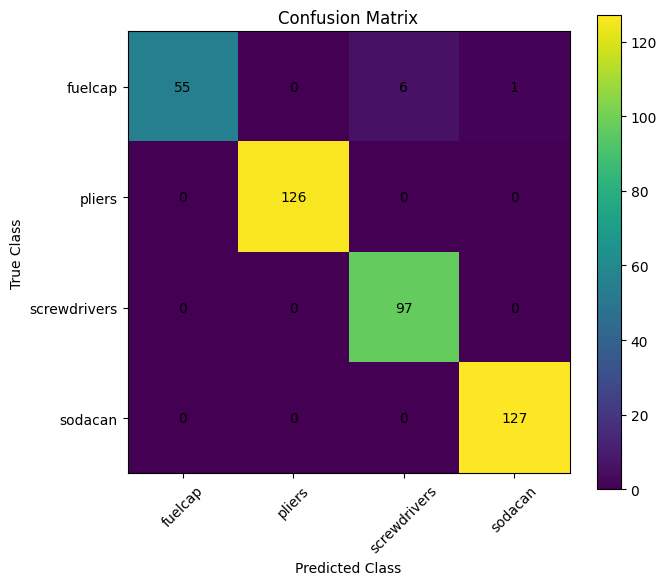

In [27]:
plt.figure(figsize=(7, 6))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(
    np.arange(len(CLASS_NAMES)),
    CLASS_NAMES,
    rotation=45
)

plt.yticks(
    np.arange(len(CLASS_NAMES)),
    CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

# Put numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [28]:
X_test_dequant = scaler.dequantize(
    X_test_int8
)

print("Shape:", X_test_dequant.shape)
print("dtype:", X_test_dequant.dtype)

print("Min:", X_test_dequant.min())
print("Max:", X_test_dequant.max())
print("Mean:", X_test_dequant.mean())
print("Std:", X_test_dequant.std())

Shape: (412, 64)
dtype: float32
Min: -4.0
Max: 4.0
Mean: -0.037912805
Std: 0.9440986


In [29]:
int8_loss, int8_accuracy = model.evaluate(
    X_test_dequant,
    y_test,
    verbose=1
)

print()
print("INT8/dequantized accuracy:", int8_accuracy)
print("INT8/dequantized loss:", int8_loss)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9830 - loss: 0.0977

INT8/dequantized accuracy: 0.9830096960067749
INT8/dequantized loss: 0.09774383902549744


In [30]:
quant_error = (
    X_test_std -
    X_test_dequant
)

print("Quantization error")
print("------------------")

print(
    "Mean absolute error:",
    np.mean(np.abs(quant_error))
)

print(
    "Maximum absolute error:",
    np.max(np.abs(quant_error))
)

print(
    "RMSE:",
    np.sqrt(
        np.mean(
            quant_error ** 2
        )
    )
)

Quantization error
------------------
Mean absolute error: 0.007999071
Maximum absolute error: 0.015746832
RMSE: 0.009195967


# saving the .nyp files

In [31]:
from pathlib import Path
import numpy as np

FEATURE_DIR = Path(
    r"D:\PROJECTS\64feature_NN\RGB_NN\features"
)

FEATURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# FP32 feature files
# ------------------------------------------------------------

np.save(
    FEATURE_DIR / "X_train.npy",
    X_train
)

np.save(
    FEATURE_DIR / "y_train.npy",
    y_train
)

np.save(
    FEATURE_DIR / "X_val.npy",
    X_val
)

np.save(
    FEATURE_DIR / "y_val.npy",
    y_val
)

np.save(
    FEATURE_DIR / "X_test.npy",
    X_test
)

np.save(
    FEATURE_DIR / "y_test.npy",
    y_test
)

# ------------------------------------------------------------
# Standardized feature files
# ------------------------------------------------------------

np.save(
    FEATURE_DIR / "X_train_std.npy",
    X_train_std
)

np.save(
    FEATURE_DIR / "X_val_std.npy",
    X_val_std
)

np.save(
    FEATURE_DIR / "X_test_std.npy",
    X_test_std
)

# ------------------------------------------------------------
# INT8 feature files
# ------------------------------------------------------------

np.save(
    FEATURE_DIR / "X_train_int8.npy",
    X_train_int8
)

np.save(
    FEATURE_DIR / "X_val_int8.npy",
    X_val_int8
)

np.save(
    FEATURE_DIR / "X_test_int8.npy",
    X_test_int8
)

print("Feature files saved to:")
print(FEATURE_DIR)

Feature files saved to:
D:\PROJECTS\64feature_NN\RGB_NN\features


In [32]:
for file in sorted(FEATURE_DIR.glob("*.npy")):
    data = np.load(file)

    print(
        f"{file.name:25s}",
        data.shape,
        data.dtype
    )

X_test.npy                (412, 64) float32
X_test_int8.npy           (412, 64) int8
X_test_std.npy            (412, 64) float32
X_train.npy               (1870, 64) float32
X_train_int8.npy          (1870, 64) int8
X_train_std.npy           (1870, 64) float32
X_val.npy                 (384, 64) float32
X_val_int8.npy            (384, 64) int8
X_val_std.npy             (384, 64) float32
y_test.npy                (412,) int64
y_train.npy               (1870,) int64
y_val.npy                 (384,) int64


# Save the model

In [33]:
model.save(
    FEATURE_DIR / "fod_mlp.keras"
)

In [35]:
import json

FEATURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ============================================================
# 1. Save class names
# ============================================================

with open(
    FEATURE_DIR / "classes.json",
    "w"
) as f:
    json.dump(
        CLASS_NAMES,
        f,
        indent=4
    )


# ============================================================
# 2. Save feature names
# ============================================================

with open(
    FEATURE_DIR / "feature_names.json",
    "w"
) as f:
    json.dump(
        list(FEATURE_NAMES),
        f,
        indent=4
    )


# ============================================================
# 3. Save scaler
# ============================================================

scaler.save(
    FEATURE_DIR / "scaler.npz"
)


print("Saved successfully:")
print(
    FEATURE_DIR / "classes.json"
)
print(
    FEATURE_DIR / "feature_names.json"
)
print(
    FEATURE_DIR / "scaler.npz"
)

Saved successfully:
D:\PROJECTS\64feature_NN\RGB_NN\features\classes.json
D:\PROJECTS\64feature_NN\RGB_NN\features\feature_names.json
D:\PROJECTS\64feature_NN\RGB_NN\features\scaler.npz


In [37]:
import json

with open(
    FEATURE_DIR / "training_history.json",
    "w"
) as f:
    json.dump(
        {
            key: [float(x) for x in values]
            for key, values in history.history.items()
        },
        f,
        indent=4
    )

print("Training history saved.")

Training history saved.
